Running EKF with CasADi Analytical Jacobians...

--- Step 4 Final Metrics ---
Avg Execution Time : 0.000272s per step (Real-time OK)
Longitudinal RMSE  : 0.2697 m
Lateral (d) RMSE   : 0.2210 m
Final Bias Estimate: 1.5837 m (Error: 0.0837 m)


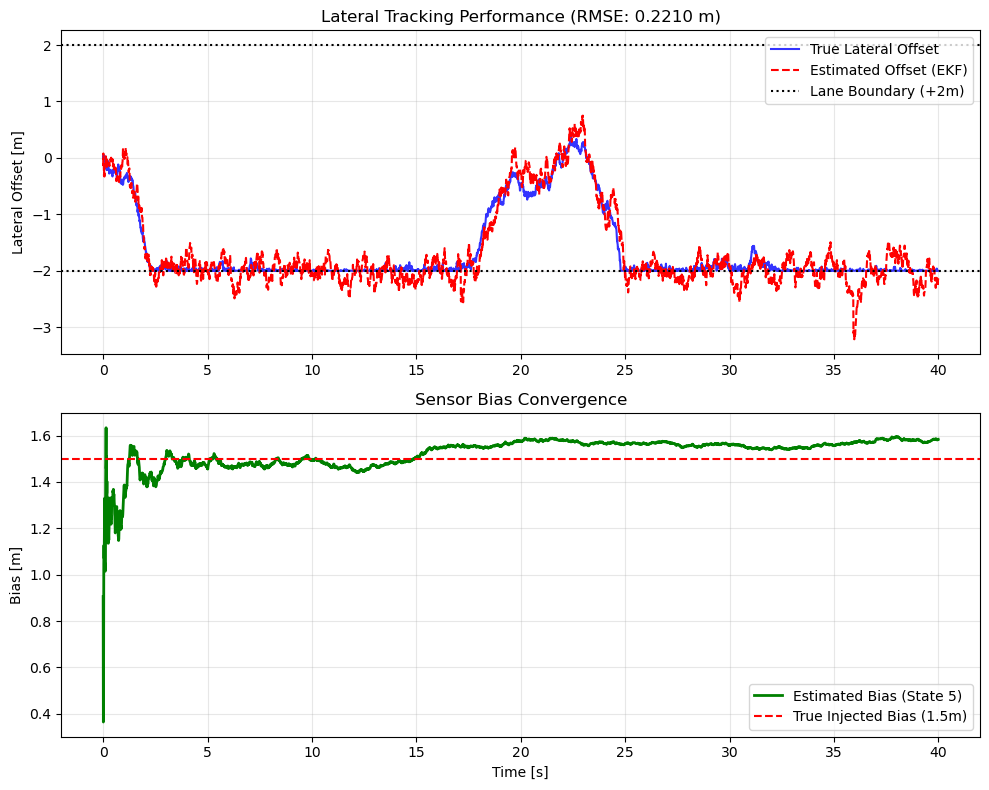

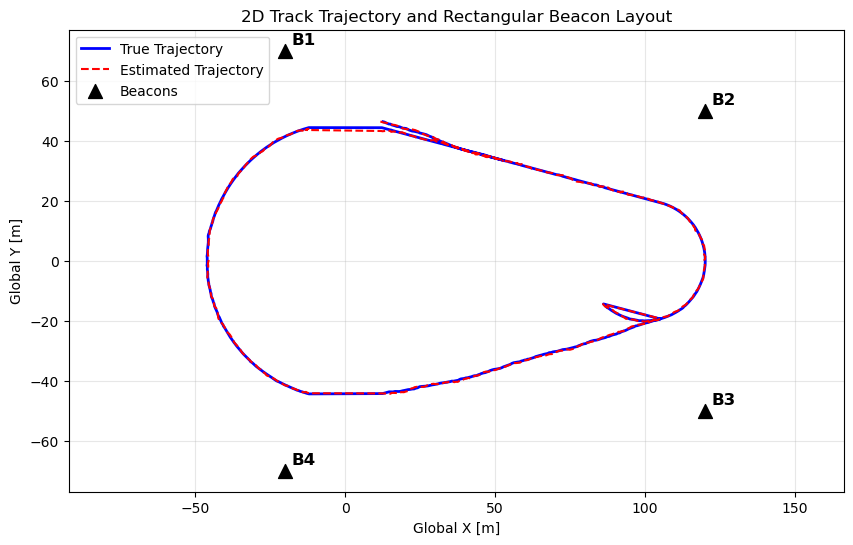

In [3]:
import numpy as np
import casadi as cs
import matplotlib.pyplot as plt
import time

np.random.seed(42)

# ============================================================
# 1. 시뮬레이션 및 시스템 파라미터 셋업
# ============================================================
h_dt = 0.01  # 100Hz 샘플링
v_target = 10.0
k_vel = 0.1
R_meas_std = 1.5
TRUE_BIAS = 1.5

# 프로세스 노이즈 및 측정 노이즈 공분산 (5-State)
Q = np.diag([0.001, 0.01, 0.001, 0.01, 1e-6])
R_mat = (R_meas_std**2) * np.eye(4)

x0 = np.array([[0.0], [10.0], [0.0], [0.0], [0.0]])
P0 = np.diag([1.0, 0.5, 0.5, 0.1, 2.0])

# 비콘 4개 직사각형 배치 (Observability 확보)
beacons = np.array([[-20, 70], [120, 50], [120, -50], [-20, -70]])
ny = len(beacons)

# ============================================================
# 2. 복합 트랙 모델 및 야코비안 자동 미분 (CasADi)
# ============================================================
# 트랙 기하학적 파라미터 (Figure 1)
R1, R2, d_centers = 48.0, 22.0, 100.0
sin_alpha = (R1 - R2) / d_centers
alpha = np.arcsin(sin_alpha)

L_str = d_centers * np.cos(alpha)
L_curveB = R2 * (np.pi + 2 * alpha)
L_curveA = R1 * (np.pi - 2 * alpha)
L_tot = 2 * L_str + L_curveB + L_curveA

P_A_top_x, P_A_top_y = R1 * np.sin(alpha), R1 * np.cos(alpha)
P_B_bot_x, P_B_bot_y = d_centers + R2 * np.sin(alpha), -R2 * np.cos(alpha)

# CasADi 심볼릭 변수 셋업
s_sym, vs_sym = cs.MX.sym('s'), cs.MX.sym('vs')
d_sym, vd_sym = cs.MX.sym('d'), cs.MX.sym('vd')
b_sym = cs.MX.sym('b')
state_sym = cs.vertcat(s_sym, vs_sym, d_sym, vd_sym, b_sym)

s_mod = cs.fmod(s_sym, L_tot)

# Segment 1: Top Straight
x1, y1, psi1 = P_A_top_x + s_mod * cs.cos(-alpha), P_A_top_y + s_mod * cs.sin(-alpha), -alpha
# Segment 2: Right Curve
s2 = s_mod - L_str
theta2 = (np.pi/2 - alpha) - s2 / R2
x2, y2, psi2 = d_centers + R2 * cs.cos(theta2), R2 * cs.sin(theta2), theta2 - np.pi/2
# Segment 3: Bottom Straight
s3 = s_mod - (L_str + L_curveB)
x3, y3, psi3 = P_B_bot_x + s3 * cs.cos(-np.pi + alpha), P_B_bot_y + s3 * cs.sin(-np.pi + alpha), -np.pi + alpha
# Segment 4: Left Curve
s4 = s_mod - (2 * L_str + L_curveB)
theta4 = (-np.pi/2 - alpha) - s4 / R1
x4, y4, psi4 = R1 * cs.cos(theta4), R1 * cs.sin(theta4), theta4 - np.pi/2

# 조건부 트랙 맵핑 (if_else 적용)
x_c = cs.if_else(s_mod < L_str, x1, cs.if_else(s_mod < L_str + L_curveB, x2, cs.if_else(s_mod < 2 * L_str + L_curveB, x3, x4)))
y_c = cs.if_else(s_mod < L_str, y1, cs.if_else(s_mod < L_str + L_curveB, y2, cs.if_else(s_mod < 2 * L_str + L_curveB, y3, y4)))
psi_c = cs.if_else(s_mod < L_str, psi1, cs.if_else(s_mod < L_str + L_curveB, psi2, cs.if_else(s_mod < 2 * L_str + L_curveB, psi3, psi4)))

# Global X, Y 좌표 계산 (측면 오프셋 d 반영)
X_global = x_c - d_sym * cs.sin(psi_c)
Y_global = y_c + d_sym * cs.cos(psi_c)

# 비콘 측정 수식 (비콘 인덱스 2번(우상단)에 Bias b_sym 추가)
h_list = []
for i in range(ny):
    dist = cs.sqrt((X_global - beacons[i, 0])**2 + (Y_global - beacons[i, 1])**2)
    h_list.append(dist + b_sym if i == 2 else dist)
h_sym = cs.vertcat(*h_list)

# Python에서 호출할 CasADi 함수 생성 (이게 누락됐던 핵심!)
calc_global_pos = cs.Function('calc_global_pos', [s_sym, d_sym], [X_global, Y_global])
h_func = cs.Function('h_func', [state_sym], [h_sym])
C_func = cs.Function('C_func', [state_sym], [cs.jacobian(h_sym, state_sym)])

# ============================================================
# 3. 파이썬 EKF 코어 함수
# ============================================================
def f_discrete(x, dt):
    s, v_s, d, v_d, b = x.flatten()
    return np.array([
        [s + v_s * dt],
        [v_s + k_vel * (v_target - v_s) * dt],
        [d + v_d * dt],
        [v_d],
        [b]
    ])

def get_A_matrix(x, dt):
    A = np.eye(5)
    A[0, 1] = dt
    A[1, 1] = 1 - k_vel * dt
    A[2, 3] = dt
    return A

# ============================================================
# 4. 메인 EKF 시뮬레이션 루프 (System-Estimator Separation)
# ============================================================
n_steps = 4000
x_true = x0.copy()
x_est = x0.copy()
P_est = P0.copy()

true_history, est_history = [], []

print("Running EKF with CasADi Analytical Jacobians...")
start_exec = time.time()

for k in range(n_steps):
    # --- 1. True Plant Propagation (실제 차량) ---
    w_true = np.random.multivariate_normal(np.zeros(5), Q).reshape(-1, 1)
    w_true[4, 0] = 0 # 실제 바이어스는 고정값
    x_true = f_discrete(x_true, h_dt) + w_true
    x_true[4, 0] = TRUE_BIAS # 물리적 에러 1.5m 강제 주입
    
    # 물리적 제약조건 방어 (Soft boundary)
    if x_true[2, 0] > 2.0: x_true[2, 0] = 2.0
    elif x_true[2, 0] < -2.0: x_true[2, 0] = -2.0

    # --- 2. Generate Measurement ---
    z_real = np.array(h_func(x_true)).reshape(-1, 1) + np.random.normal(0, R_meas_std, (ny, 1))

    # --- 3. Prediction ---
    x_pred = f_discrete(x_est, h_dt)
    A_k = get_A_matrix(x_est, h_dt)
    P_pred = A_k @ P_est @ A_k.T + Q
    P_pred = (P_pred + P_pred.T) / 2.0

    # --- 4. Correction (CasADi C행렬 적용!) ---
    C_k = np.array(C_func(x_pred)).astype(float) # 제대로 계산된 야코비안 행렬
    z_hat = np.array(h_func(x_pred)).reshape(-1, 1)
    
    innovation = z_real - z_hat
    S = C_k @ P_pred @ C_k.T + R_mat
    K = P_pred @ C_k.T @ np.linalg.inv(S)
    
    x_est = x_pred + K @ innovation
    P_est = (np.eye(5) - K @ C_k) @ P_pred
    P_est = (P_est + P_est.T) / 2.0

    true_history.append(x_true.flatten())
    est_history.append(x_est.flatten())

exec_time = (time.time() - start_exec) / n_steps

# ============================================================
# 5. RMSE 계산 및 평가
# ============================================================
true_history = np.array(true_history)
est_history = np.array(est_history)
t_axis = np.arange(n_steps) * h_dt

# 초기 100스텝(수렴 전 Burn-in) 제외하고 정상상태 RMSE 계산
rmse_s = np.sqrt(np.mean((true_history[100:, 0] - est_history[100:, 0])**2))
rmse_d = np.sqrt(np.mean((true_history[100:, 2] - est_history[100:, 2])**2))
bias_error = abs(TRUE_BIAS - est_history[-1, 4])

print(f"\n--- Step 4 Final Metrics ---")
print(f"Avg Execution Time : {exec_time:.6f}s per step (Real-time OK)")
print(f"Longitudinal RMSE  : {rmse_s:.4f} m")
print(f"Lateral (d) RMSE   : {rmse_d:.4f} m")
print(f"Final Bias Estimate: {est_history[-1, 4]:.4f} m (Error: {bias_error:.4f} m)")

# ============================================================
# 6. 보고서용 3종 그래프 출력
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# [Graph 1] Lateral Offset
ax1.plot(t_axis, true_history[:, 2], 'b-', label='True Lateral Offset', alpha=0.8)
ax1.plot(t_axis, est_history[:, 2], 'r--', label='Estimated Offset (EKF)')
ax1.axhline(2.0, color='k', linestyle=':', label='Lane Boundary (+2m)')
ax1.axhline(-2.0, color='k', linestyle=':')
ax1.set_title(f'Lateral Tracking Performance (RMSE: {rmse_d:.4f} m)')
ax1.set_ylabel('Lateral Offset [m]')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# [Graph 2] Bias Estimation
ax2.plot(t_axis, est_history[:, 4], 'g-', linewidth=2, label='Estimated Bias (State 5)')
ax2.axhline(TRUE_BIAS, color='r', linestyle='--', label='True Injected Bias (1.5m)')
ax2.set_title('Sensor Bias Convergence')
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Bias [m]')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

# [Graph 3] 2D Trajectory
X_true_arr, Y_true_arr = [], []
X_est_arr, Y_est_arr = [], []

# 연산 속도를 위해 5스텝마다 렌더링
for i in range(0, n_steps, 5):
    xt, yt = calc_global_pos(float(true_history[i, 0]), float(true_history[i, 2]))
    xe, ye = calc_global_pos(float(est_history[i, 0]), float(est_history[i, 2]))
    X_true_arr.append(float(xt))
    Y_true_arr.append(float(yt))
    X_est_arr.append(float(xe))
    Y_est_arr.append(float(ye))

plt.figure(figsize=(10, 6))
plt.plot(X_true_arr, Y_true_arr, 'b-', label='True Trajectory', linewidth=2)
plt.plot(X_est_arr, Y_est_arr, 'r--', label='Estimated Trajectory')
plt.scatter(beacons[:, 0], beacons[:, 1], c='black', marker='^', s=100, label='Beacons')
for i, (bx, by) in enumerate(beacons):
    plt.text(bx + 2, by + 2, f'B{i+1}', fontsize=12, fontweight='bold')
plt.title('2D Track Trajectory and Rectangular Beacon Layout')
plt.xlabel('Global X [m]')
plt.ylabel('Global Y [m]')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()